In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv("C:\\Users\\libin_urv2w13\\Desktop\\mljourney\\project\\housing.csv")

In [66]:
df.isnull().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        11
population             0
households             0
median_income          0
median_house_value     0
ocean_proximity        0
dtype: int64

In [67]:
df.shape

(1708, 10)

In [68]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [69]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan,strategy="most_frequent")
df[["total_bedrooms"]] = imputer.fit_transform(df[["total_bedrooms"]])
df.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [70]:
df["ocean_proximity"].value_counts()

ocean_proximity
NEAR BAY     1145
INLAND        450
<1H OCEAN     113
Name: count, dtype: int64

In [71]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([("encoder",OneHotEncoder(sparse_output=True),["ocean_proximity"])],remainder="passthrough")
df = pd.DataFrame(ct.fit_transform(df), columns=ct.get_feature_names_out())
df.head()

,encoder__ocean_proximity_<1H OCEAN,encoder__ocean_proximity_INLAND,encoder__ocean_proximity_NEAR BAY,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__total_rooms,remainder__total_bedrooms,remainder__population,remainder__households,remainder__median_income,remainder__median_house_value
0,0.0,0.0,1.0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,0.0,0.0,1.0,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,0.0,0.0,1.0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,0.0,0.0,1.0,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,0.0,0.0,1.0,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


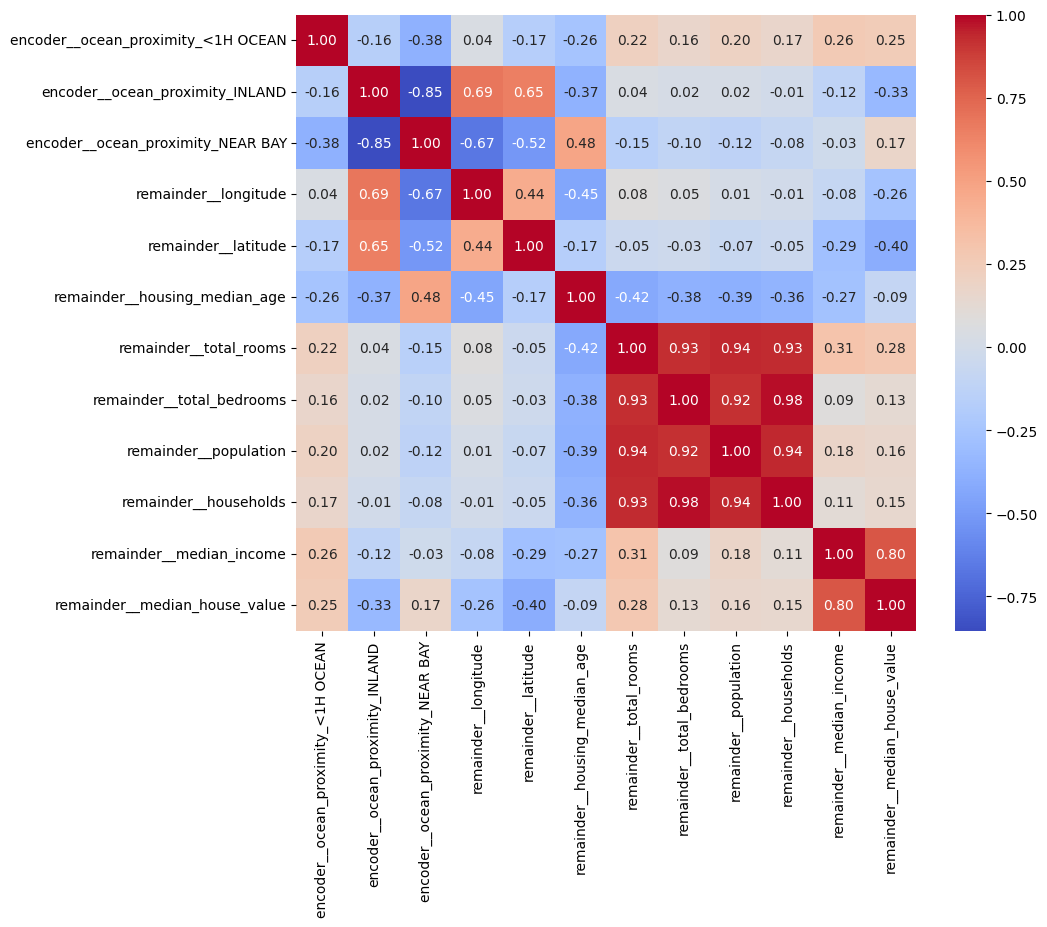

In [72]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [73]:
df.columns

Index(['encoder__ocean_proximity_<1H OCEAN', 'encoder__ocean_proximity_INLAND',
       'encoder__ocean_proximity_NEAR BAY', 'remainder__longitude',
       'remainder__latitude', 'remainder__housing_median_age',
       'remainder__total_rooms', 'remainder__total_bedrooms',
       'remainder__population', 'remainder__households',
       'remainder__median_income', 'remainder__median_house_value'],
      dtype='object')

In [74]:
df.columns = df.columns.str.replace("remainder__", "")
df.columns = df.columns.str.replace("encoder__", "")
df.columns

Index(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_NEAR BAY', 'longitude', 'latitude',
       'housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value'],
      dtype='object')

In [75]:
x = df[["ocean_proximity_<1H OCEAN","ocean_proximity_INLAND","ocean_proximity_NEAR BAY","total_rooms","population","households","median_income"]]
y = df["median_house_value"]
x.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,total_rooms,population,households,median_income
0,0.0,0.0,1.0,880.0,322.0,126.0,8.3252
1,0.0,0.0,1.0,7099.0,2401.0,1138.0,8.3014
2,0.0,0.0,1.0,1467.0,496.0,177.0,7.2574
3,0.0,0.0,1.0,1274.0,558.0,219.0,5.6431
4,0.0,0.0,1.0,1627.0,565.0,259.0,3.8462


In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [78]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred)*100)

75.31658609246294


In [79]:
import joblib
joblib.dump(lr, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']